# Circuit Translations
Apart from the qiskit circuit model, quantum launcher also is also compatible with cirq, moreover you can use quantum launcher's translations to transform circuits between frameworks with ease.\
Let's define a qiskit circuit:

In [3]:
import qiskit

circuit = qiskit.QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.x(0)
circuit.draw()

┌───┐     ┌───┐
q_0: ┤ H ├──■──┤ X ├
     └───┘┌─┴─┐└───┘
q_1: ─────┤ X ├─────
          └───┘

Now to obtain it's cirq version you can just use quantum launcher's Translation class ans specify 'cirq' as language:

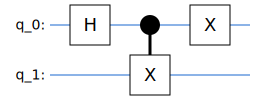

In [4]:
from quantum_launcher.base.translator import Translation
from cirq.contrib.svg import SVGCircuit

cirq_circuit = Translation.get_translation(circuit, 'cirq')
SVGCircuit(cirq_circuit)

## Cirq Backend

Quantum launcher also comes with a cirq backend and thanks to translations you can use it interchangeably with qiskit backends:

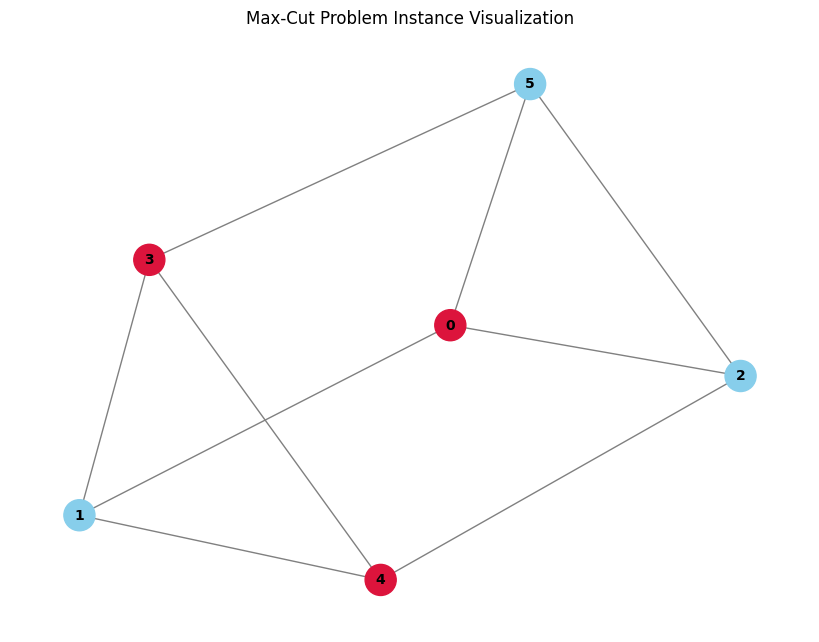

In [5]:
from quantum_launcher.problems import MaxCut
from quantum_launcher.routines.qiskit_routines import QAOA
from quantum_launcher.routines.cirq_routines import CirqBackend
from quantum_launcher.launcher import QuantumLauncher 

problem = MaxCut.from_preset('default')
algorithm = QAOA(p=2)
backend = CirqBackend()
launcher = QuantumLauncher(problem, algorithm, backend)
results = launcher.run()
problem.visualize(results.best_bitstring)